<a href="https://colab.research.google.com/github/RamMohanHota/ML-and-PYTHON-LAB/blob/main/_09_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
plt.style.use('seaborn-v0_8-whitegrid')
from scipy.spatial import ConvexHull as ConvexHull
from sklearn.model_selection import train_test_split

In [2]:
data=datasets.load_iris()

In [3]:
x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=2)

In [4]:
x=np.array(data.data)
y=np.array(data.target)
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
X=np.delete(x,np.array([1,2]),axis=1)

In [6]:
y_transformed = []
for i in y:
  if i == 0:
    y_transformed.append(1)
  else:
    y_transformed.append(-1)
y = np.array(y_transformed)

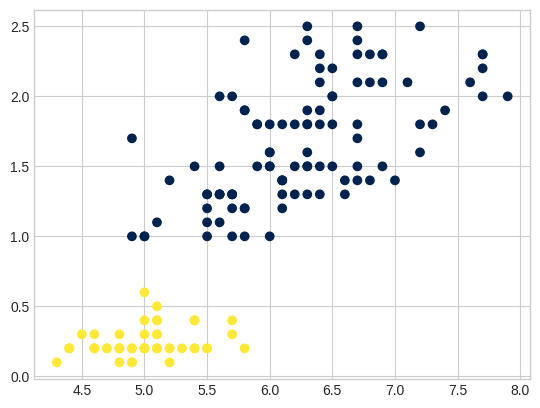

In [7]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='cividis')

In [8]:
def objective_fn(w):
    return cp.norm(w)**2/2

In [9]:
def fit(X,y):
    w=cp.Variable(2)
    b=cp.Variable()
    constraint=[(y[i] * (w.T@X[i] + b)-1) >=0 for i in range(len(X))]
    problem=cp.Problem(cp.Minimize(objective_fn(w)),constraint)
    problem.solve()
    print(problem.status)
    w=w.value
    b=b.value
    support_vectors=[]
    for x in X:
        tmp=w @ x.T + b
        if 1-tmp<10**(-8) and 1-tmp > -10**(-8):
            support_vectors.append(x)
        if -1-tmp<10**(-8) and -1-tmp > -10**(-8):
            support_vectors.append(x)
    support_vectors=np.unique(support_vectors,axis=0)
    return support_vectors,w,b

In [10]:
def predict(X, w, b):

  return np.sign(X @ w + b)

In [11]:
support_vector , w , b = fit(X, y)

optimal


In [12]:
# Create a 2-dimensional version of x_test by dropping the same columns as X
x_test_2d = np.delete(x_test, np.array([1, 2]), axis=1)

y_pred = predict(x_test_2d, w, b)
print(y_pred)

[ 1.  1. -1.  1.  1. -1.  1. -1. -1.  1.  1.  1.  1.  1. -1. -1.  1. -1.
 -1. -1. -1. -1. -1. -1. -1.  1.  1. -1.  1. -1.]


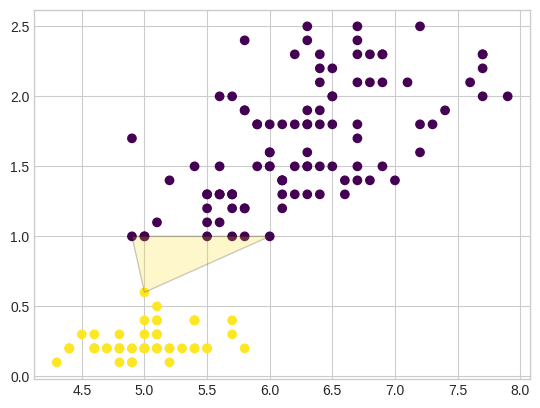

In [13]:
import matplotlib.patches as patches

def encircle(x, y, ax=None, **kw):
    if not ax: ax = plt.gca()
    p = np.c_[x, y]
    hull = ConvexHull(p)
    polygon = patches.Polygon(p[hull.vertices, :], closed=True, **kw)
    ax.add_patch(polygon)
    return polygon

plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')

# Encircle the support vectors
if support_vector is not None and len(support_vector) > 0:
    encircle(support_vector[:, 0], support_vector[:, 1], ec="k", fc="gold", alpha=0.2)

plt.show()

In [14]:
from sklearn.metrics import accuracy_score

# Transform y_test to be consistent with the prediction labels (-1 and 1)
y_test_transformed = np.where(y_test == 0, 1, -1)

accuracy = accuracy_score(y_test_transformed, y_pred)
print(f"Accuracy Score: {accuracy}")

Accuracy Score: 1.0
